In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for a clean, professional aesthetic
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

# Load the benchmark report
with open('../benchmarks/results/comprehensive_eval.json', 'r') as f:
    report = json.load(f)

phase_1 = report['phase_1_scale_sweep']
phase_2 = report['phase_2_ef_sweep']

print("Diagnostic data loaded successfully.")

Diagnostic data loaded successfully.


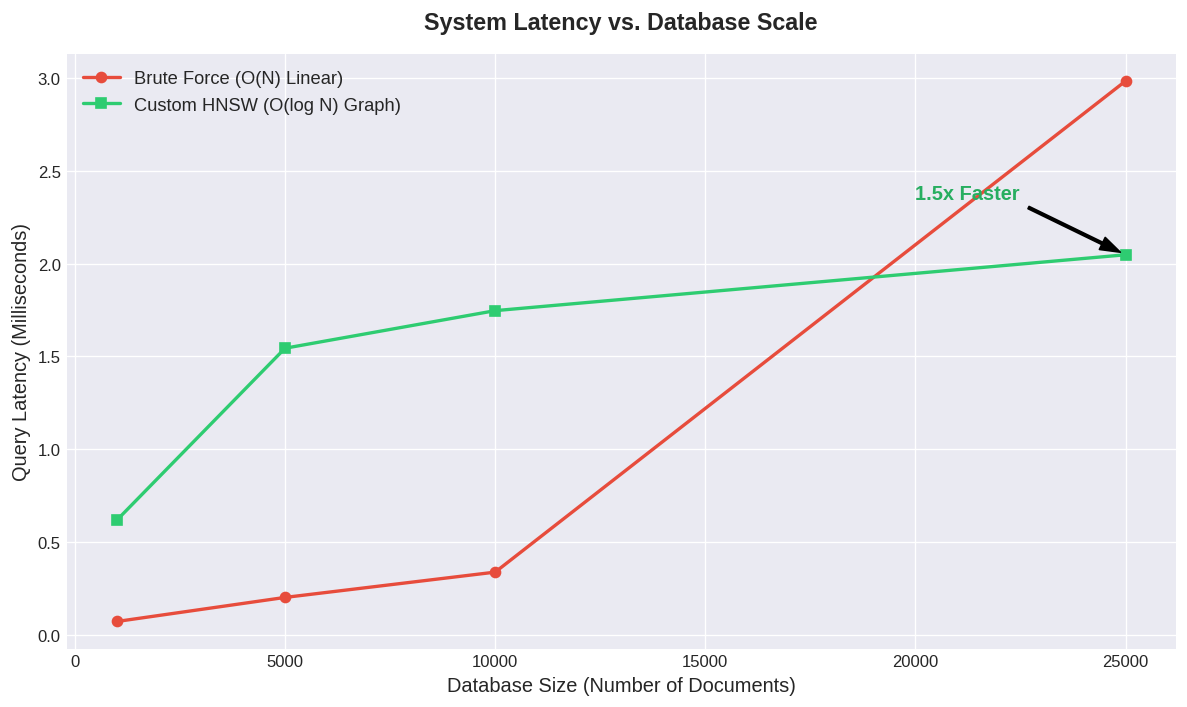

In [4]:
# Extract Phase 1 Data
sizes = sorted([int(k) for k in phase_1.keys()])
bf_latencies = [phase_1[str(size)]['avg_brute_force_ms'] for size in sizes]
hnsw_latencies = [phase_1[str(size)]['avg_hnsw_ms'] for size in sizes]

# Initialize Plot
plt.figure(figsize=(10, 6))

# Plot lines
plt.plot(sizes, bf_latencies, marker='o', linewidth=2, color='#e74c3c', label='Brute Force (O(N) Linear)')
plt.plot(sizes, hnsw_latencies, marker='s', linewidth=2, color='#2ecc71', label='Custom HNSW (O(log N) Graph)')

# Formatting
plt.title('System Latency vs. Database Scale', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Database Size (Number of Documents)', fontsize=12)
plt.ylabel('Query Latency (Milliseconds)', fontsize=12)
plt.legend(fontsize=11)

# Annotate the final speedup multiplier
final_size = str(sizes[-1])
speedup = phase_1[final_size]['speedup_factor']
plt.annotate(f"{speedup:.1f}x Faster", 
             xy=(sizes[-1], hnsw_latencies[-1]), 
             xytext=(sizes[-1] * 0.8, hnsw_latencies[-1] + np.max(bf_latencies)*0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.savefig('../benchmarks/plots/latency_vs_scale.png')
plt.show()

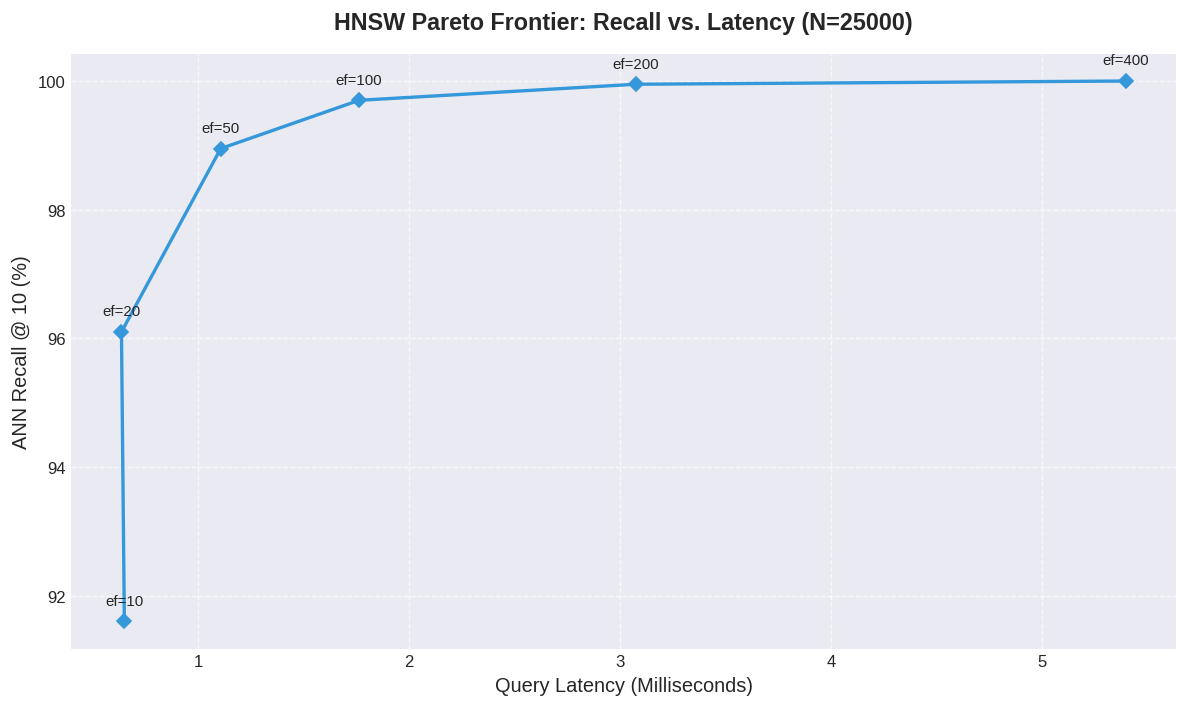

In [5]:
# Extract Phase 2 Data
ef_values = sorted([int(k) for k in phase_2.keys()])
recalls = [phase_2[str(ef)]['avg_ann_recall'] * 100 for ef in ef_values]
latencies = [phase_2[str(ef)]['avg_hnsw_ms'] for ef in ef_values]

# Initialize Plot
plt.figure(figsize=(10, 6))

# Plot the frontier
plt.plot(latencies, recalls, marker='D', linestyle='-', linewidth=2, color='#3498db')

# Annotate the ef_search values on the points
for i, ef in enumerate(ef_values):
    plt.annotate(f"ef={ef}", 
                 (latencies[i], recalls[i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=9)

# Formatting
plt.title(f'HNSW Pareto Frontier: Recall vs. Latency (N={sizes[-1]})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Query Latency (Milliseconds)', fontsize=12)
plt.ylabel('ANN Recall @ 10 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../benchmarks/plots/pareto_frontier.png')
plt.show()